# Compare GeneBayes and PIES on similar dataset size (gnomAD v2 sample sizes)

In [33]:
# --- make parent folder importable ---
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # points to Paper_SFS/

# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, average_precision_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, hypergeom
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm
from scipy.integrate import simpson, trapezoid, cumulative_trapezoid
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import dask
import dask.dataframe as dd
import re
import dask.bag as db
import csv
from tqdm import tqdm
from dask.diagnostics import ProgressBar
from concurrent.futures import ProcessPoolExecutor
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json

# --- import your project modules (files in Paper_SFS/) ---
import Gen_SFS_with_s_demography
import plot_SFS

# (optional) pull specific functions
# from Gen_SFS_with_s import calc_SFS_k
# from plot_SFS import plot_sfs


## Create a hash table of predicted SFS for NFE demography given mutation rate distribution and selection coefficients

In [2]:
# def load_mu_params_for_demography(demography, epoch):

#     if demography == "NFE" or demography == "schraiber_et_al":
#         df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
#     else:
#         df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')
         
#     return df_mu_var_p
    

# def load_demography_result(json_file, demography, epoch_no):
#     with open(json_file, "r") as f:
#         records = json.load(f)
#     for rec in records:
#         if rec["demography"] == demography and rec["epoch_no"] == epoch_no:
#             return rec

#     return {"params" : []}


In [6]:
# def get_SFS_on_ancestry(demography, epoch, n, mu_low_mu = 2e-10, json_file = "../Demography_estimation/demography_results.json", pkl_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/"):

#     df_mu_var_p = load_mu_params_for_demography(demography = demography, epoch = epoch)
#     MR = df_mu_var_p['MR'].values
#     mean_mu_values = df_mu_var_p['mean_mu'].values
#     var_mu_values = df_mu_var_p['var_mu'].values
#     p_mu_values = df_mu_var_p['p_mu'].values

#     slope, intercept, r_value, p_value, std_err = linregress(MR[:-1], mean_mu_values[:-1]/(4*14448))

#     mean_mus = np.insert(mean_mu_values, 0, (slope*0.004 + intercept)*4*14448)
#     var_mus = np.insert(var_mu_values, 0, 1e-23*(4*14448)**2)
#     p_mus = np.insert(p_mu_values, 0, 0)

#     mu_var_pairs = np.column_stack((mean_mus, var_mus))
#     s_values = -np.logspace(np.log10(10**-6), np.log10(100), num=500)  # 500 negative values
#     s_values = np.append(s_values, 0)  # Include neutral case (total 501 values)

#     # Load demography parameters
#     params_rec = load_demography_result(json_file, demography, epoch)

#     st_time = time.time()
#     SFS_eachp = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var_pairs(mu_var_pairs, s_values, demography = demography, n = n, 
#                                                                          params = params_rec["params"], model = "original", kmax = 5000)  
    
#     high_mu_pkl_filename = pkl_folder+f"SFS_gamma_{demography}_downsampled.pkl"
#     with open(high_mu_pkl_filename, "wb") as f:
#         pickle.dump(SFS_eachp, f)
#     en_time = time.time()
#     print(f"Done in {en_time-st_time}s")

#     results = Parallel(n_jobs=-1)(
#         delayed(Gen_SFS_with_s_demography.compute_SFS)(mu_low_mu, s, demography = demography, n=n, params = params_rec["params"], model = "original", kmax = 5000) for s in s_values
#     )
    
#     # Reshape results into (s_count, 5001)
#     s_count = len(s_values)
#     SFS_values = np.array([sfs for _, _, _, sfs in results])    
#     SFS_matrix = SFS_values.reshape(s_count, -1)
#     print(SFS_matrix.shape)

#     low_mu_pkl_filename = pkl_folder+f"SFS_low_{demography}_downsampled.pkl"
#     with open(low_mu_pkl_filename, "wb") as f:
#         pickle.dump(SFS_matrix, f)
#     print("Done")

#     p_mus_broadcasted = p_mus[:, np.newaxis, np.newaxis]
#     SFS_low_mu = SFS_matrix[np.newaxis, :, :]
#     SFS_each = (1-p_mus_broadcasted)*SFS_eachp + p_mus_broadcasted*SFS_low_mu

#     pkl_filename = pkl_folder+f"SFS_{demography}_downsampled.pkl"
#     with open(pkl_filename, "wb") as f:
#         pickle.dump(SFS_each, f)
#     print("Done") 

In [7]:
# # NFE
# get_SFS_on_ancestry("NFE", epoch = 3, n = 251496)

Done in 8483.155871629715s
(501, 5001)
Done
Done


### Calculate the selection coefficient using PIES on downsampled gnomad v4 to v2 data

In [2]:
def construct_per_gene_dfs(df):
    """
    Constructs a dictionary of dataframes for each gene with the relevant columns for analysis.
    """
    gene_dfs = {gene_id: group.reset_index(drop=True) for gene_id, group in df.groupby("gene_id")}
    return gene_dfs



def gene_specific_LL_full(curr_gene_id, gene_df, Bell_tensor, pnull_dict, AC_col):
    '''
    Returns the whole likelihood function as a function of s
    curr_gene_id: Ensembl id of the current gene
    gene_df : Dataframe storing info for curr_gene_id gene
    Bell_tensor: Same as SFSs, stores the predicted SFS for all Roulette values and 
                 500 selection values from (-10**-6 to -100) + neutral (s = 0) for allele counts from 0 to 5000
    pnull_dict: Dictionary with three items "stop_gained", "splice_donor_variant" and "splice_acceptor_variant". Values stores the prob of misannotation
    AC_col: Stores the allele count column name for the demography being analyzed
    '''
    # Initialize the LL vector for the SFS
    LL_vec = np.zeros(Bell_tensor.shape[1] - 1)  # Initialize the LL vector for the SFS
    
    for annotation, pnull in pnull_dict.items():
        annotation_df = gene_df[gene_df["most_severe_consequence2"] == annotation].reset_index(drop=True)
        mu_inds = annotation_df["MR_rank"].astype(int).values
        ACs = annotation_df[AC_col].astype(int).values
        
        p_neuts = Bell_tensor[mu_inds, -1, ACs] # Neutral probabilities
        p_Ss = Bell_tensor[mu_inds, :-1, ACs] # Selection probabilities
        
        # Calculate the log-likelihood for each variant
        Ls = np.log10(pnull * p_neuts[:, None] + (1 - pnull) * p_Ss).T
        # Sum the log-likelihoods across all variants for each annotation
        LLs = np.sum(Ls, axis=1)
        LL_vec += LLs
    return curr_gene_id, LL_vec



def optimize_gene_s_ret_logL(curr_gene_id, gene_df, Bell_tensor, pnull_dict, AC_col):
    """
    Compute the full LL curve and return the maximum LL for this gene.
    """
    _, LL_vec = gene_specific_LL_full(curr_gene_id, gene_df, Bell_tensor, pnull_dict, AC_col)
    return np.max(LL_vec)



# Likelihood for pnull estimate combining over 
def p_misannot_s(params, gene_dfs, Bell_tensor, AC_col):

    stop_gain, splice_donor, splice_acceptor = params
    pnull_dict = {"stop_gained": stop_gain, "splice_donor_variant": splice_donor, "splice_acceptor_variant": splice_acceptor}

    results = Parallel(n_jobs=-1)(
        delayed(optimize_gene_s_ret_logL)(
            curr_gene_id,
            gene_dfs[curr_gene_id],
            Bell_tensor,
            pnull_dict,
            AC_col
        )
        for curr_gene_id in gene_dfs.keys()
    )

    neg_loglikelihood = -np.sum(results)

    return neg_loglikelihood

In [ ]:
# Load the gnomAD LoF data
df_LoF_orig = pd.read_csv("../Data/gnomad_lof_full.txt.gz", sep="\t", compression="gzip")

In [3]:
# # Add extra Downsampling column
# TARGET_AN = 251496

# # Pull arrays
# M = df_LoF_orig["AN_NFE"].to_numpy(dtype=np.int64)  # population size (total alleles)
# K = df_LoF_orig["AC_NFE"].to_numpy(dtype=np.int64)  # number of "successes" (alt alleles)

# # Do not upsample: if a site has fewer alleles than TARGET_AN, sample all available
# n = np.minimum(M, TARGET_AN).astype(np.int64)

# # Optional: reproducible randomness
# rng = np.random.default_rng(45)

# # Exact: X ~ Hypergeom(M, K, n)
# df_LoF_orig["AC_NFE_ds_1"] = hypergeom.rvs(M=M, n=K, N=n, random_state=rng)

# # If you also want the downsampled AN stored:
# df_LoF_orig["AN_NFE_ds_1"] = n
# df_LoF_orig

,#CHROM,POS,REF,ALT,QUAL,MR,gene_id,transcript_id,allele_count,allele_number,...,AC_EAS,AC_FIN,AC_NFE,AC_SAS,most_severe_consequence2,MR_rank,AC_NFE_ds,AN_NFE_ds,AC_NFE_ds_1,AN_NFE_ds_1
0,10,49203,G,T,TFBS,0.174,ENSG00000261456,ENST00000568584,1,1427464,...,0.0,0.0,1.0,0.0,stop_gained,16,0,251496,0,251496
1,10,49208,G,A,TFBS,0.128,ENSG00000261456,ENST00000568584,4,1429486,...,0.0,0.0,3.0,0.0,stop_gained,12,0,251496,2,251496
2,10,49217,G,A,TFBS,0.117,ENSG00000261456,ENST00000568584,0,1432036,...,0.0,0.0,0.0,0.0,stop_gained,11,0,251496,0,251496
3,10,49232,C,A,TFBS,0.030,ENSG00000261456,ENST00000568584,1,1432762,...,0.0,0.0,0.0,0.0,stop_gained,3,0,251496,0,251496
4,10,179992,A,C,high,0.041,ENSG00000015171,ENST00000381604,0,1415244,...,0.0,0.0,0.0,0.0,splice_acceptor_variant,4,0,251496,0,251496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236932,9,138121969,C,G,TFBS,0.041,ENSG00000148408,ENST00000371372,0,1449300,...,0.0,0.0,0.0,0.0,stop_gained,4,0,251496,0,251496
5236933,9,138121982,C,T,TFBS,0.105,ENSG00000148408,ENST00000371372,0,1447812,...,0.0,0.0,0.0,0.0,stop_gained,10,0,251496,0,251496
5236934,9,138121992,G,A,TFBS,0.139,ENSG00000148408,ENST00000371372,0,1445676,...,0.0,0.0,0.0,0.0,stop_gained,13,0,251496,0,251496
5236935,9,138121993,G,A,TFBS,0.186,ENSG00000148408,ENST00000371372,0,1445722,...,0.0,0.0,0.0,0.0,stop_gained,17,0,251496,0,251496


In [4]:
ac_col = "AC_NFE_ds"
AN_col = "AN_NFE_ds"
kmax = 5000
demography = "NFE"

# Filters out the CES genes and variants with allele counts >5000
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])

df_LoF = df_LoF_orig[~(df_LoF_orig['gene_id'].isin(CE_genes)) & (df_LoF_orig[ac_col]<=kmax)].reset_index(drop = True)

# Get LoFs in form a dictionary with LoF dataframe as values and Ensembl gene_id as item keys
gene_dfs = construct_per_gene_dfs(df_LoF)

# Predicted theoretical SFSs for all Roulette values and 500 selection values from (-10**-6 to -100) + neutral (s = 0) for allele counts from 0 to kmax
with open(f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}_downsampled.pkl", "rb") as f:
    SFSs = pickle.load(f)

s_values = -np.logspace(np.log10(10**-6), np.log10(100), num=500)  # Grid of selection values. SFSs 2nd index num+1 (grid + neutral) values. Here it is 500+1 values


In [4]:
# # Fix probability of misannotation by taking the max value of each shet optimized likelihood

# # Initial parameters
# pnull_dict = {"stop_gained": 0.02, "splice_donor_variant": 0.05, "splice_acceptor_variant": 0.05}

# stop_gain = pnull_dict["stop_gained"]
# splice_donor = pnull_dict["splice_donor_variant"]
# splice_acceptor = pnull_dict["splice_acceptor_variant"]
# initial_params_pnull = [stop_gain, splice_donor, splice_acceptor]

# # Bounds of parameters
# bound_pnull = [(1e-10, 0.5)] * len(initial_params_pnull)

# # Find the pnull which maximizes the likelihood of observing LoF SFS over all genes 
# result_pnull = minimize(
#         p_misannot_s,
#         initial_params_pnull,
#         args=(gene_dfs, SFSs, ac_col),
#         bounds=bound_pnull,
#         method="Nelder-Mead",
#         options={"disp": True}
#     )

# pnull_dict["stop_gained"] = result_pnull.x[0]
# pnull_dict["splice_donor_variant"] = result_pnull.x[1]
# pnull_dict["splice_acceptor_variant"] = result_pnull.x[2]

# # Store pnull in outdir_pnull
# os.makedirs("Pnull_values", exist_ok=True)
# pd.Series(pnull_dict, name="pnull").to_csv(f"Pnull_values/{demography}_downsampled.csv")
# # pnull results
# print("\nFinal Estimates:")
# print(f"pnull: {pnull_dict}")

# # Find the likelihood of observing LoF SFS as a function of s for all genes and store them
# pnull_dict = pd.read_csv(f"Pnull_values/{demography}_downsampled.csv", index_col=0)["pnull"].to_dict()

# LL_dict = {}

# # Prepare input list for parallel run for calculating likelihoods
# jobs = [
#     delayed(gene_specific_LL_full)(
#         curr_gene_id,
#         gene_dfs[curr_gene_id],
#         SFSs,
#         pnull_dict,
#         ac_col
#     )
#     for curr_gene_id in gene_dfs.keys()
# ]

# # Run in parallel (n_jobs = number of cores you want to use)
# results = Parallel(n_jobs=-1)(jobs)

# # Collect results
# for curr_gene_id, s_value in results:
#     LL_dict[curr_gene_id] = s_value

# pkl_filename = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/LL_{demography}_downsampled.pkl"
# with open(pkl_filename, "wb") as f:
#     pickle.dump(LL_dict, f)
# print(f"Calculated likelihood for {demography} demography - downsampled")

Optimization terminated successfully.
         Current function value: 378542.252966
         Iterations: 38
         Function evaluations: 68

Final Estimates:
pnull: {'stop_gained': np.float64(0.021749078926422756), 'splice_donor_variant': np.float64(0.06067086537285633), 'splice_acceptor_variant': np.float64(0.06640007630029693)}
Calculated likelihood for NFE demography - downsampled


In [5]:
# # Get likelihoods for independent downsampled dataset. Use the same pnull estimates
# # Find the likelihood of observing LoF SFS as a function of s for all genes and store them
# pnull_dict = pd.read_csv(f"Pnull_values/{demography}_downsampled.csv", index_col=0)["pnull"].to_dict()

# LL_dict = {}

# # Prepare input list for parallel run for calculating likelihoods
# jobs = [
#     delayed(gene_specific_LL_full)(
#         curr_gene_id,
#         gene_dfs[curr_gene_id],
#         SFSs,
#         pnull_dict,
#         ac_col
#     )
#     for curr_gene_id in gene_dfs.keys()
# ]

# # Run in parallel (n_jobs = number of cores you want to use)
# results = Parallel(n_jobs=-1)(jobs)

# # Collect results
# for curr_gene_id, s_value in results:
#     LL_dict[curr_gene_id] = s_value

# pkl_filename = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/LL_{demography}_downsampled_independent.pkl"
# with open(pkl_filename, "wb") as f:
#     pickle.dump(LL_dict, f)
# print(f"Calculated likelihood for {demography} demography - downsampled independent column")

Calculated likelihood for NFE demography - downsampled independent column


In [5]:
def log10sumexp(a, axis=None):
    """Stable log10(sum(10**a))"""
    return logsumexp(a * np.log(10), axis=axis) / np.log(10)

def per_gene_posterior_ests(LL_vec, s_vec, prior_mean, prior_SD, n_grid=1000):
    """
    LL_vec: log10-likelihood evaluated at s_vec
    s_vec : grid of the parameter (log10(s) values)
    prior_mean, prior_SD: mean/sd of the Normal prior on s_vec-scale
    Returns:
      integr_range: grid
      log10_post_density: log10 posterior density on grid (integrates to ~1)
    """
    s_vec = np.asarray(s_vec, dtype=float)
    LL_vec = np.asarray(LL_vec, dtype=float)

    # 1) grid for integration
    dx = s_vec[1] - s_vec[0]

    # 2) prior density on this scale
    prior_pdf = norm.pdf(s_vec, loc=prior_mean, scale=prior_SD)
    # avoid log10(0) underflow
    prior_pdf = np.maximum(prior_pdf, np.finfo(float).tiny)
    log10_prior = np.log10(prior_pdf)

    # 3) unnormalized log10 posterior density
    log10_post_unnorm = LL_vec + log10_prior

    # 4) normalize as a *density*: ∫ p(x) dx = 1  ->  sum p(x_i)*dx ≈ 1
    log10Z = log10sumexp(log10_post_unnorm + np.log10(dx))
    log10_post = log10_post_unnorm - log10Z

    return log10_post


def compute_LPs(LL_dict, gb_df, s_vec = -np.logspace(np.log10(10**-6), np.log10(100), num=500), SD = 0.5):
    """
    Computes the log posterior estimates for each gene based on the log-likelihoods
    and a specified prior distribution.
    """
    prior_dict = {gb_df["ensg"][i] : gb_df["prior_mean"][i] for i in range(len(gb_df))}

    s_vec = -s_vec
    # Assume s_vec is a NumPy array
    if np.any(s_vec <= 0):
        raise ValueError("Error: s_vec contains negative values.")
    
    if not np.all(np.diff(s_vec) > 0):
        raise ValueError("Error: s_vec is not sorted in ascending order.")
    
    s_vec = np.log10(s_vec)  # log10 transformed

    post_dict = {}
    for gene_id, LL_vec in LL_dict.items():
        if prior_dict.get(gene_id) is not None:
            prior_mean = np.log10(prior_dict[gene_id])
            prior_SD = SD
        else:
            prior_mean = -2
            prior_SD = 2

        Lpost_vals = per_gene_posterior_ests(LL_vec, s_vec, prior_mean, prior_SD)
        post_dict[gene_id] = {"Lpost_vals": Lpost_vals}

    return post_dict

In [6]:
with open(f"/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/LL_{demography}_downsampled.pkl", "rb") as f:
    LL_dict = pickle.load(f)

df_genebayes = pd.read_csv("../Data/LoF/GeneBayes.txt", sep="\t")
post_dict = compute_LPs(LL_dict, df_genebayes, s_values)

In [7]:
def LL_to_dist(LL_vec, x_vec_log10, alphas=(0.1, 0.05)):
    """
    LL_vec: log10 unnormalized posterior/likelihood evaluated on x-grid
    x_vec_log10: x grid where x = log10(-s) (must be increasing)
    Returns summary stats for t = -s (positive) on linear scale.
    """
    x = np.asarray(x_vec_log10, dtype=float)
    LL = np.asarray(LL_vec, dtype=float)

    # Ensure increasing grid
    if np.any(np.diff(x) <= 0):
        raise ValueError("x_vec_log10 must be strictly increasing (sorted).")

    dx = x[1] - x[0]  # assumes uniform grid; if not uniform, handle separately

    # --- density in x-space: p(x) ∝ 10^LL(x)
    LL_shift = LL - np.nanmax(LL)  # do NOT modify input array
    w = 10.0 ** LL_shift           # unnormalized weights

    # Normalize as a *density* over x: sum p(x_i) dx = 1
    Z = np.sum(w) * dx
    p_x = w / Z                    # density in x

    # Transform to linear t = 10^x (= -s):
    t = 10.0 ** x
    # Jacobian: p_t(t) = p_x(x) / (t ln 10)
    p_t = p_x / (t * np.log(10.0))

    # Renormalize in t-space (should already be ~1, but do it for safety)
    mass = trapezoid(p_t, t)
    p_t = p_t / mass

    cdf = cumulative_trapezoid(p_t, t, initial=0.0)
    # cdf[-1] = 1.0  # guard numerical drift

    # Summary stats on t (= -s)
    t_mean = trapezoid(p_t * t, t)
    t_median = t[np.searchsorted(cdf, 0.5, side="left").clip(0, len(t)-1)]
    t_mode = t[np.argmax(p_t)]

    # Two-sided equal-tail credible intervals
    CIs = {}
    for alpha in alphas:
        lo_q = alpha / 2
        hi_q = 1 - alpha / 2
        lo = t[np.searchsorted(cdf, lo_q, side="left").clip(0, len(t)-1)]
        hi = t[np.searchsorted(cdf, hi_q, side="left").clip(0, len(t)-1)]
        CIs[alpha] = (lo, hi)

    return t_mean, t_median, t_mode, CIs


def infer_summary_stats(LL_dict, post_dict, s_val, alphas=(0.1, 0.05)):
    rows = []

    x_vec_log10 = np.log10(-s_val)
    
    for gene_id, LL_vec in LL_dict.items():
        L_mean, L_median, L_mode, L_CIs = LL_to_dist(LL_vec, x_vec_log10, alphas)

        post_vec = post_dict[gene_id]["Lpost_vals"]
        P_mean, P_median, P_mode, P_CIs = LL_to_dist(post_vec, x_vec_log10, alphas)

        row = {
            "gene_id": gene_id,
            "L_mean": L_mean,
            "L_median": L_median,
            "L_mode": L_mode,
            "Posterior_mean": P_mean,
            "Posterior_median": P_median,
            "Posterior_mode": P_mode,
        }
        for alpha in alphas:
            row[f"LL_CI{int(alpha*100)}_lower"] = L_CIs[alpha][0]
            row[f"LL_CI{int(alpha*100)}_upper"] = L_CIs[alpha][1]
            row[f"Posterior_CI{int(alpha*100)}_lower"] = P_CIs[alpha][0]
            row[f"Posterior_CI{int(alpha*100)}_upper"] = P_CIs[alpha][1]

        rows.append(row)

    print(f"{len(rows)} genes were summarized")
    return pd.DataFrame(rows)


In [24]:
df_summary = infer_summary_stats(LL_dict, post_dict, s_values)

17052 genes were summarized


In [17]:
df_gene_names = pd.read_csv("../Data/ENS2Gene.txt", sep="\t", header=None, names=["gene_id", "gene_name"])
df_summary = df_summary.merge(df_gene_names, on = "gene_id", how = "left")

# merge with GeneBayes for comparison
df_summary = df_summary.merge(df_genebayes, left_on = 'gene_id', right_on = 'ensg', how='left')
df_summary = df_summary.drop(['ensg', 'hgnc'], axis = 1)

df_s_het_Weghorn = pd.read_csv("../Data/LoF/Weghorn_MBE_s_het.txt", sep="\t")
# merge with s_het (Weghorn et al., MBE, 2019) for comparison
df_summary = df_summary.merge(df_s_het_Weghorn[["Gene", "s_het_drift", "low_drift"]], left_on = 'gene_name', right_on = 'Gene', how='left')
df_summary = df_summary.drop(['Gene'], axis = 1)

df_s_het_Agarwal = pd.read_csv("../Data/LoF/Agarwal_et_al_elife.txt", sep="\t")
# merge with s_het (Agarwal et al., eLife, 2023) for comparison
df_summary = df_summary.merge(df_s_het_Agarwal[["Gene", "log10_ci_low", "log10_map"]], left_on = 'gene_name', right_on = 'Gene', how='left')
df_summary = df_summary.drop(['Gene'], axis = 1)

df_s_het_Sun = pd.read_excel("../Data/LoF/Regeneron_2024_shet.xlsx", sheet_name = "table_s2")
df_summary = df_summary.merge(df_s_het_Sun[["GeneId", "mean", "shet_lower", "shet_upper"]], left_on = 'gene_id', right_on = 'GeneId', how='left')
df_summary = df_summary.drop(['GeneId'], axis = 1)

In [18]:
df_summary = df_summary.dropna()
df_summary

,gene_id,L_mean,L_median,L_mode,Posterior_mean,Posterior_median,Posterior_mode,LL_CI10_lower,LL_CI10_upper,Posterior_CI10_lower,...,post_mean,post_lower_95,post_upper_95,s_het_drift,low_drift,log10_ci_low,log10_map,mean,shet_lower,shet_upper
0,ENSG00000000419,0.007282,0.004048,0.000001,0.013818,0.013190,0.011379,0.000003,0.023810,0.003623,...,0.019119,0.006617,0.036341,0.019605,0.000889,-5.555776,-1.713579,0.024759,0.019870,0.030884
1,ENSG00000000457,0.107916,0.080503,0.000001,0.050208,0.042980,0.025634,0.025634,0.243654,0.015864,...,0.016873,0.005009,0.032754,0.012033,0.000889,-4.870693,-1.906930,0.025370,0.021197,0.030500
2,ENSG00000000460,0.001638,0.000341,0.000001,0.003764,0.003366,0.001669,0.000002,0.007042,0.000663,...,0.002704,0.000714,0.006110,0.004307,0.000889,-6.096414,-3.610349,0.004463,0.004158,0.004793
3,ENSG00000000938,0.071104,0.057746,0.000001,0.057059,0.049819,0.039921,0.024705,0.162338,0.023810,...,0.038938,0.019626,0.064758,0.101739,0.002812,-1.409306,-0.867088,0.062363,0.046726,0.083431
4,ENSG00000000971,1.139621,0.140053,0.093313,0.113456,0.100463,0.080503,0.064509,1.487115,0.053636,...,0.033209,0.015950,0.055968,0.095456,0.008891,-1.910274,-1.556715,0.050856,0.041791,0.061753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16871,ENSG00000271303,8.425104,0.218111,0.000001,0.012206,0.007307,0.001388,0.000007,55.397093,0.000891,...,0.004956,0.000485,0.016323,0.019762,0.000889,-5.389634,-0.908054,0.011281,0.008739,0.014534
16877,ENSG00000272047,0.001270,0.000101,0.000001,0.004891,0.003901,0.001608,0.000002,0.007307,0.000769,...,0.003130,0.000226,0.010293,0.008263,0.000889,-6.195536,-4.071653,0.007206,0.005738,0.009045
16878,ENSG00000272325,0.132376,0.001797,0.000001,0.042543,0.024705,0.016460,0.000002,0.064509,0.007582,...,0.059673,0.020518,0.124946,0.110970,0.000889,-2.438083,-0.805617,0.041067,0.025993,0.064295
16879,ENSG00000272333,22.673635,11.752771,0.954904,1.473790,1.066734,0.590940,0.920297,83.145678,0.379453,...,0.493372,0.245340,0.797261,0.176555,0.028117,-0.981334,-0.594500,0.723785,0.489208,0.969884


### Benchmarks

In [19]:
# Benchmark dataset
with open("../Data/LoF/gene_lists.pkl", "rb") as f:
    gene_lists = pickle.load(f)

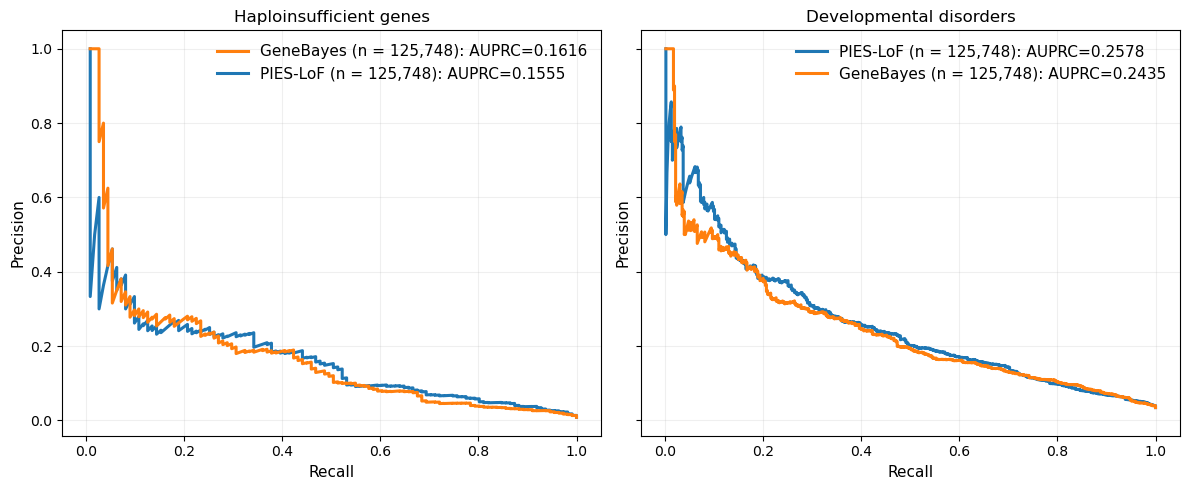

In [14]:
def precision_recall_ranked(ranked_ids, benchmark_ids):
    """
    ranked_ids: 1D array/list of ranked gene IDs (the universe)
    benchmark_ids: iterable of benchmark gene IDs (positives, may include IDs not in universe)

    Returns precision, recall computed on positives that are present in the universe.
    """
    ranked_ids = np.asarray(ranked_ids)
    bench = set(benchmark_ids)

    is_pos = np.fromiter((g in bench for g in ranked_ids), dtype=bool, count=len(ranked_ids))

    TP = np.cumsum(is_pos)
    FP = np.cumsum(~is_pos)

    # Only positives that can possibly be recovered
    P = is_pos.sum()
    if P == 0:
        # No overlap: undefined recall curve; return empty arrays (or zeros)
        return np.array([]), np.array([]), 0, 0

    FN = P - TP
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return precision, recall, P, len(bench)

MA_genes = gene_lists['MacArthurHIgenes']
NDD600 = gene_lists['NDD600']

def plot_benchmarks(df_sfac, df_labels, bench_arr, labs, method_labels, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    axes = axes.flatten()

    universe = df_sfac["gene_id"].to_numpy()

    for idx, bench in enumerate(bench_arr):
        legend_entries = []  # (auc, handle, label)

        for c in df_labels:
            df_sort = df_sfac.sort_values(by=c, ascending=False)
            ranked = df_sort["gene_id"].to_numpy()

            precision, recall, P_in_universe, P_total = precision_recall_ranked(ranked, bench)

            if precision.size == 0:
                continue

            auc = np.trapezoid(precision, recall)

            line, = axes[idx].plot(
                recall, precision, lw = 2.2,
                label=f"{method_labels[c]}: AUPRC={auc:.4f}"
            )

            legend_entries.append(
                (auc, line, f"{method_labels[c]}: AUPRC={auc:.4f}")
            )

        # ---- sort legend by AUPRC (descending) ----
        legend_entries.sort(key=lambda x: x[0], reverse=True)

        if legend_entries:
            handles = [e[1] for e in legend_entries]
            labels  = [e[2] for e in legend_entries]
            axes[idx].legend(handles, labels, fontsize=11, frameon = False)
        
        axes[idx].set_xlabel("Recall", fontsize = 11)
        axes[idx].set_ylabel("Precision", fontsize = 11)
        axes[idx].set_title(f"{labs[idx]}", fontsize = 12)
        axes[idx].grid(True, alpha=0.2, lw=0.8)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()

labs = ["Haploinsufficient genes",
        "Developmental disorders"]

bench_arr = [MA_genes, 
             NDD600]

df_labels = ["Posterior_CI5_lower",
             "post_lower_95"#,
             # "shet_lower",
             # "low_drift",
             # "log10_ci_low",
             # "LOEUF"
             ]

method_labels = {"post_lower_95": "GeneBayes (n = 125,748)", "Posterior_CI5_lower": "PIES-LoF (n = 125,748)"}

plot_benchmarks(df_summary, df_labels, bench_arr=bench_arr, labs=labs, method_labels = method_labels, filename="../Figures/benchmark_LoF_downsampled.svg")

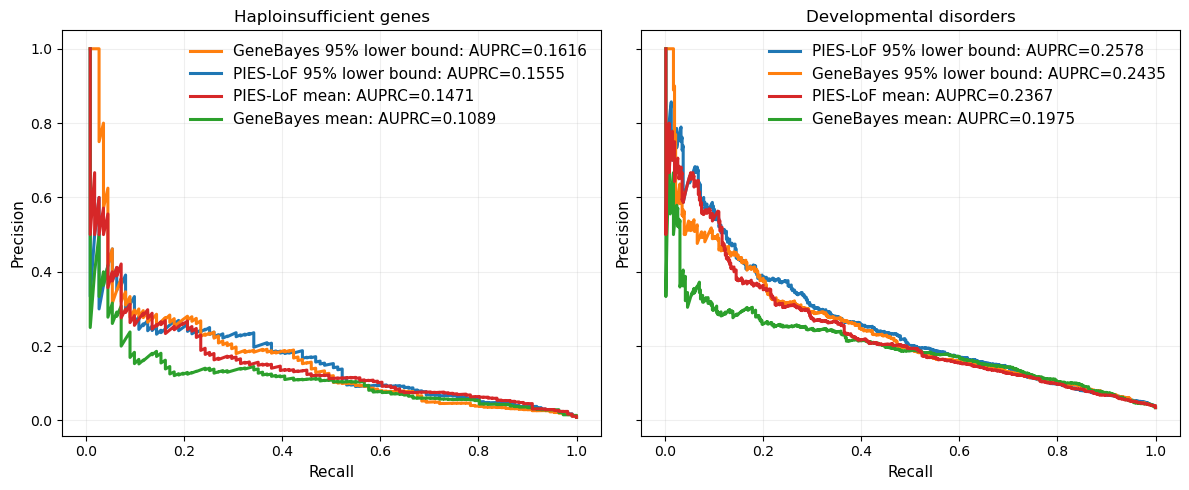

In [16]:
def precision_recall_ranked(ranked_ids, benchmark_ids):
    """
    ranked_ids: 1D array/list of ranked gene IDs (the universe)
    benchmark_ids: iterable of benchmark gene IDs (positives, may include IDs not in universe)

    Returns precision, recall computed on positives that are present in the universe.
    """
    ranked_ids = np.asarray(ranked_ids)
    bench = set(benchmark_ids)

    is_pos = np.fromiter((g in bench for g in ranked_ids), dtype=bool, count=len(ranked_ids))

    TP = np.cumsum(is_pos)
    FP = np.cumsum(~is_pos)

    # Only positives that can possibly be recovered
    P = is_pos.sum()
    if P == 0:
        # No overlap: undefined recall curve; return empty arrays (or zeros)
        return np.array([]), np.array([]), 0, 0

    FN = P - TP
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return precision, recall, P, len(bench)

MA_genes = gene_lists['MacArthurHIgenes']
NDD600 = gene_lists['NDD600']

def plot_benchmarks(df_sfac, df_labels, bench_arr, labs, method_labels, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    axes = axes.flatten()

    universe = df_sfac["gene_id"].to_numpy()

    for idx, bench in enumerate(bench_arr):
        legend_entries = []  # (auc, handle, label)

        for c in df_labels:
            df_sort = df_sfac.sort_values(by=c, ascending=False)
            ranked = df_sort["gene_id"].to_numpy()

            precision, recall, P_in_universe, P_total = precision_recall_ranked(ranked, bench)

            if precision.size == 0:
                continue

            auc = np.trapezoid(precision, recall)

            line, = axes[idx].plot(
                recall, precision, lw = 2.2,
                label=f"{method_labels[c]}: AUPRC={auc:.4f}"
            )

            legend_entries.append(
                (auc, line, f"{method_labels[c]}: AUPRC={auc:.4f}")
            )

        # ---- sort legend by AUPRC (descending) ----
        legend_entries.sort(key=lambda x: x[0], reverse=True)

        if legend_entries:
            handles = [e[1] for e in legend_entries]
            labels  = [e[2] for e in legend_entries]
            axes[idx].legend(handles, labels, fontsize=11, frameon = False)
        
        axes[idx].set_xlabel("Recall", fontsize = 11)
        axes[idx].set_ylabel("Precision", fontsize = 11)
        axes[idx].set_title(f"{labs[idx]}", fontsize = 12)
        axes[idx].grid(True, alpha=0.2, lw=0.8)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()

labs = ["Haploinsufficient genes",
        "Developmental disorders"]

bench_arr = [MA_genes, 
             NDD600]

df_labels = ["Posterior_CI5_lower",
             "post_lower_95",
             "post_mean",
             "Posterior_mean"#,
             #"shet_lower",
             #"low_drift",
             #"log10_ci_low"
             ]

method_labels = {"post_lower_95": "GeneBayes 95% lower bound", "Posterior_CI5_lower": "PIES-LoF 95% lower bound",
                 "post_mean": "GeneBayes mean", "Posterior_mean": "PIES-LoF mean", 
                 "low_drift": r"$s_{het}$ Weghorn et al.", "log10_ci_low": "Agarwal et al.", "shet_lower": "RGC-ME"}


plot_benchmarks(df_summary, df_labels, bench_arr=bench_arr, labs=labs, method_labels = method_labels, filename="../Figures/benchmark_LoF_downsampled_comp.svg")

### Find p value for difference in AUPRC of two methods 

In [20]:
def build_labels_and_scores(df_summary, score_col1, score_col2, benchmark_ids):
    """
    Returns y, score1, score2 aligned on df_summary rows.
    """
    df = df_summary.copy()

    bench_set = set(benchmark_ids)

    # Binary labels: 1 if gene is in benchmark AND in universe
    y = df["gene_id"].isin(bench_set).astype(int).to_numpy()

    # Scores
    s1 = df[score_col1].to_numpy()
    s2 = df[score_col2].to_numpy()

    return y, s1, s2


def pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    y = np.asarray(y).astype(int)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)

    ap1 = average_precision_score(y, s1)
    ap2 = average_precision_score(y, s2)
    delta_obs = ap1 - ap2

    n = len(y)
    deltas = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if y[idx].min() == y[idx].max():
            deltas[b] = np.nan
            continue
        deltas[b] = (
            average_precision_score(y[idx], s1[idx])
            - average_precision_score(y[idx], s2[idx])
        )

    deltas = deltas[np.isfinite(deltas)]

    p_value = 2 * min((deltas <= 0).mean(), (deltas >= 0).mean())
    ci = (np.percentile(deltas, 2.5), np.percentile(deltas, 97.5))

    return {
        "AUPRC_1": ap1,
        "AUPRC_2": ap2,
        "delta": delta_obs,
        "p_value": p_value,
        "CI95": ci
    }


In [21]:
MA_genes = gene_lists['MacArthurHIgenes']
NDD600 = gene_lists['NDD600']

method_labels = {"post_lower_95": "GeneBayes", "Posterior_CI5_lower": "PIES-LoF", "post_mean": "GeneBayes mean", "Posterior_mean": "PIES-LoF mean",
                 "low_drift": r"$s_{het}$ Weghorn et al.", "log10_ci_low": "Agarwal et al.", "shet_lower": "RGC-ME"}

In [19]:
scoreA = "Posterior_CI5_lower"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


PIES-LoF AUPRC: 0.16767171853583665
GeneBayes AUPRC: 0.1733211187028189
Δ: -0.00564940016698226
p-value: 0.8098
95% CI: (np.float64(-0.04242323123502418), np.float64(0.032308976423833485))


In [20]:
scoreA = "Posterior_CI5_lower"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


ERROR! Session/line number was not unique in database. History logging moved to new session 10820
PIES-LoF AUPRC: 0.25793835963540845
GeneBayes AUPRC: 0.24661597553994502
Δ: 0.011322384095463434
p-value: 0.3212
95% CI: (np.float64(-0.011479818511764021), np.float64(0.035774724260355543))


In [23]:
scoreA = "Posterior_mean"
scoreB = "post_mean"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


PIES-LoF mean AUPRC: 0.16006759126211398
GeneBayes mean AUPRC: 0.12129270545352262
Δ: 0.038774885808591356
p-value: 0.1246
95% CI: (np.float64(-0.011194927075566874), np.float64(0.0909441890493845))


In [24]:
scoreA = "Posterior_mean"
scoreB = "post_mean"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


PIES-LoF mean AUPRC: 0.24026682801973953
GeneBayes mean AUPRC: 0.20109097045815177
Δ: 0.03917585756158776
p-value: 0.0088
95% CI: (np.float64(0.010623236831166312), np.float64(0.06881243316905142))


In [25]:
scoreA = "Posterior_mean"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


PIES-LoF mean AUPRC: 0.16006759126211398
GeneBayes AUPRC: 0.1733211187028189
Δ: -0.013253527440704932
p-value: 0.5894
95% CI: (np.float64(-0.05576878957136005), np.float64(0.03007768774882638))


In [23]:
scoreA = "Posterior_mean"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


PIES-LoF mean AUPRC: 0.24026682801973953
GeneBayes AUPRC: 0.24661597553994502
Δ: -0.006349147520205489
p-value: 0.6842
95% CI: (np.float64(-0.03216938032253482), np.float64(0.022159266069244937))


### Compare likelihoods at the point estimates provided by PIES and GeneBayes

In [25]:
# merge with GeneBayes for comparison
df_summary = df_summary.merge(df_genebayes, left_on = 'gene_id', right_on = 'ensg', how='left')
df_summary = df_summary.drop(['ensg', 'hgnc'], axis = 1)
df_summary = df_summary.dropna()

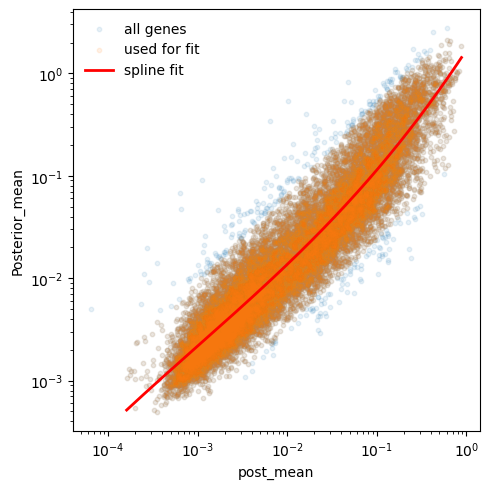

In [26]:
fit_df = df_summary[["Posterior_mean","post_mean"]].dropna()

fit_df = fit_df[(fit_df["Posterior_mean"]>0) & (fit_df["post_mean"]>0)]

x = np.log10(fit_df["post_mean"])
y = np.log10(fit_df["Posterior_mean"])
coef = np.polyfit(x, y, 1)
y_pred = np.polyval(coef, x)
residuals = y - y_pred
mad = np.median(np.abs(residuals - np.median(residuals)))

mask = np.abs(residuals) < 4 * mad

x_clean = x[mask]
y_clean = y[mask]

x_clean = x_clean.values
y_clean = y_clean.values

order = np.argsort(x_clean)

x_clean = x_clean[order]
y_clean = y_clean[order]

spline = UnivariateSpline(x_clean, y_clean, s=len(x_clean)*0.3)

df_summary["post_mean_scaled"] = np.nan

mask = df_summary["post_mean"] > 0

df_summary.loc[mask,"post_mean_scaled"] = 10**spline(
    np.log10(df_summary.loc[mask,"post_mean"])
)

plt.figure(figsize=(5,5))

plt.scatter(10**x, 10**y, s=10, alpha=0.1, label="all genes")
plt.scatter(10**x_clean, 10**y_clean, s=10, alpha=0.1, label="used for fit")

xg = np.linspace(x_clean.min(), x_clean.max(),300)
yg = spline(xg)

plt.plot(10**xg,10**yg,color="red",lw=2,label="spline fit")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("post_mean")
plt.ylabel("Posterior_mean")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [27]:
# Likelihood from independent downsampled data
with open(f"/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/LL_{demography}_downsampled_independent.pkl", "rb") as f:
    LL_dict_indep = pickle.load(f)

# columns to store results
df_summary["LL_at_Posterior_mean"] = np.nan
df_summary["LL_at_post_mean"] = np.nan

for i, row in df_summary.iterrows():

    gene = row["gene_id"]

    if gene not in LL_dict:
        continue

    LL = LL_dict_indep[gene]

    # interpolation function
    f = interp1d(
        -s_values,
        LL,
        bounds_error=False,
        fill_value="extrapolate"
    )

    df_summary.loc[i, "gene_length"] = len(gene_dfs[gene])
    df_summary.loc[i, "LL_at_Posterior_mean"] = f(row["Posterior_mean"])
    df_summary.loc[i, "LL_at_post_mean"] = f(row["post_mean_scaled"])

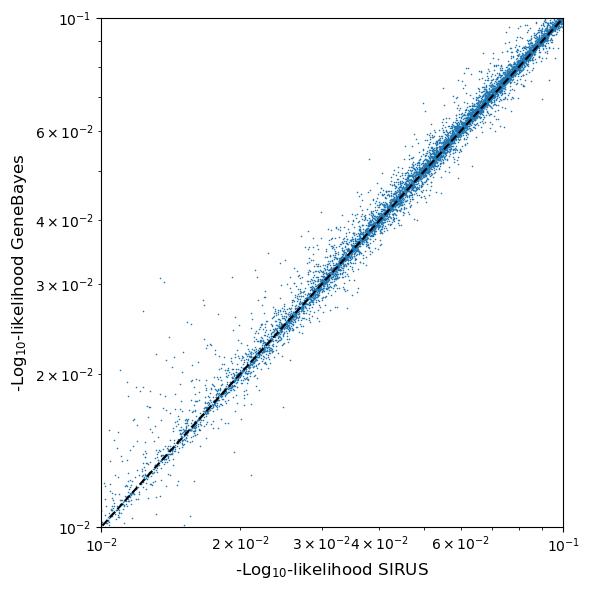

In [20]:
x = (-df_summary["LL_at_Posterior_mean"])/df_summary["gene_length"]
y = -df_summary["LL_at_post_mean"]/df_summary["gene_length"]

plt.figure(figsize=(6,6))

sns.scatterplot(
    x= x,
    y= y,
    s=1,
    alpha=1,
    edgecolor=None
)

# y = x reference line
lims = [
    np.nanmin([x.min(), y.min()]),
    np.nanmax([x.max(), y.max()])
]

plt.plot(lims, lims, 'k--', linewidth=1.5)

# plt.xlim(lims)
# plt.ylim(lims)
plt.xlim(0.01,0.1)
plt.ylim(0.01,0.1)
plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"-Log$_{10}$-likelihood SIRUS", fontsize=12)
plt.ylabel(r"-Log$_{10}$-likelihood GeneBayes", fontsize=12)

plt.tight_layout()
plt.show()

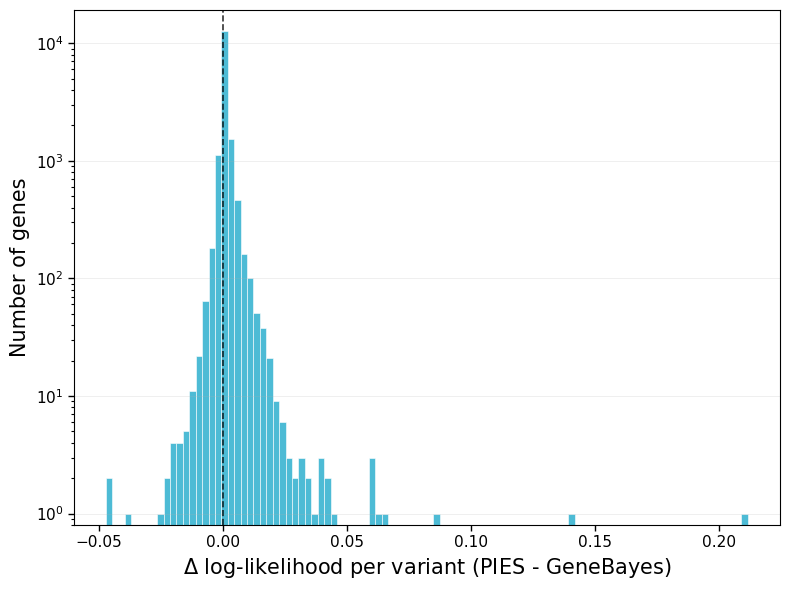

In [37]:
# Nature-like palette
NPG_BLUE = "#4DBBD5"

x = ((df_summary["LL_at_Posterior_mean"] - df_summary["LL_at_post_mean"])/ df_summary["gene_length"])

x = x.replace([np.inf, -np.inf], np.nan).dropna()

fig, ax = plt.subplots(figsize=(8, 6))

counts, bins = np.histogram(x, bins=100)

centers = 0.5 * (bins[:-1] + bins[1:])
widths = np.diff(bins)

ybase = 0.8  # positive baseline for log-scale histogram

mask = counts > 0

ax.bar(centers[mask],counts[mask] - ybase, bottom=ybase, width=widths[mask], color=NPG_BLUE, edgecolor="white", linewidth=0.4, align="center")

# ax.hist(x, bins=100, color=NPG_BLUE, edgecolor="white", linewidth=0.4, alpha=0.95)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel(r"$\Delta$ log-likelihood per variant (PIES - GeneBayes)", fontsize=15)
ax.set_ylabel("Number of genes", fontsize=15)

ax.tick_params(axis="both", which="major", labelsize=11, length=4, width=1)
ax.tick_params(axis="both", which="minor", length=2.5, width=0.8)

ax.grid(axis="y", alpha=0.2, linewidth=0.7)
ax.set_yscale("log")
ax.set_ylim(ybase, counts.max() * 1.5)

fig.tight_layout()
fig.savefig("../Figures/LL_diff_s.svg", bbox_inches="tight")
plt.show()

In [23]:
((df_summary["LL_at_Posterior_mean"]-df_summary["LL_at_post_mean"])/df_summary["gene_length"]).sum()

np.float64(12.380670470281517)